# Домашнее задание 2: Предсказание сердечного приступа.

**Козачук Олег Анатольевич**

**Датасет:** Heart Disease Classification Dataset (Kaggle)  
**Ссылка на датасет** https://www.kaggle.com/datasets/bharath011/heart-disease-classification-dataset

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    recall_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay
)
from sklearn.inspection import permutation_importance

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

RANDOM_STATE = 42

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Мы вынесли `RANDOM_STATE = 42` в отдельную переменную и будем использовать её везде, где есть случайность. Это обеспечивает **воспроизводимость** — при каждом запуске ноутбука результаты будут одинаковыми.

---

## 1. Предобработка данных

### 1.1. Загрузка и кодирование целевой переменной

In [2]:
df = pd.read_csv('/content/drive/MyDrive/Heart Attack.csv', sep = ',')

df['target'] = (df['class'] == 'positive').astype(int)
df = df.drop('class', axis=1)

print(f'Размер датасета: {df.shape}')
print(f'\nЦелевая переменная:')
print(df['target'].value_counts())

Размер датасета: (1319, 9)

Целевая переменная:
target
1    810
0    509
Name: count, dtype: int64


Мы заменили строковую переменную `class` на числовую `target`: `positive` (сердечный приступ) - 1, `negative` - 0. Это необходимо, потому что все алгоритмы sklearn работают с числами, а не со строками.

### 1.2. Удаление аномальных значений

В EDA мы обнаружили 2 записи с пульсом = 20 ударов/мин — это физиологически неправдоподобно и скорее всего является ошибкой ввода. Удаляем их.

In [3]:
print(f'Записей до: {len(df)}')
df = df[df['impluse'] >= 30].reset_index(drop=True)
print(f'Записей после удаления аномалий: {len(df)}')

Записей до: 1319
Записей после удаления аномалий: 1317


### 1.3. Обработка выбросов

В EDA мы видели, что `kcm`, `troponin` и `glucose` имеют очень сильные выбросы. Удалять эти строки нельзя — высокий тропонин у пациента с инфарктом это не ошибка, а важная информация. Поэтому используем **клиппинг**: обрезаем значения по 1-му и 99-му перцентилям. Это значит, что всё, что ниже 1% самых маленьких значений, станет равно этой нижней границе, а всё выше 99% — станет равно верхней.

In [4]:
columns_to_clip = ['kcm', 'troponin', 'glucose']

for col in columns_to_clip:
    lower = np.percentile(df[col], 1)
    upper = np.percentile(df[col], 99)
    print(f'{col}: обрезаем до [{lower:.3f}, {upper:.3f}]')
    df[col] = df[col].clip(lower, upper)

kcm: обрезаем до [0.518, 300.000]
troponin: обрезаем до [0.003, 5.988]
glucose: обрезаем до [67.160, 420.880]


### 1.4. Логарифмическое преобразование скошенных признаков

Признаки `kcm`, `troponin`, `glucose` сильно скошены вправо (у большинства пациентов маленькие значения, но у некоторых — огромные). Такие распределения могут мешать линейным моделям. Применяем `log1p(x) = ln(1 + x)` — это сжимает правый хвост и делает распределение более симметричным.

In [5]:
skewed_cols = ['kcm', 'troponin', 'glucose']

print('Асимметрия (skewness) до и после log1p:')
print('-' * 45)
for col in skewed_cols:
    skew_before = df[col].skew()
    df[col] = np.log1p(df[col])
    skew_after = df[col].skew()
    print(f'{col:10s}: {skew_before:>6.2f}  ->  {skew_after:>6.2f}')

Асимметрия (skewness) до и после log1p:
---------------------------------------------
kcm       :   4.97  ->    1.83
troponin  :   4.27  ->    2.76
glucose   :   1.77  ->    0.92


Асимметрия заметно уменьшилась — значения стали более «ровно» распределены. Это поможет, в первую очередь, логистической регрессии.

---
## 2. Разделение на обучающую и тестовую выборки

Разделяем данные в пропорции 80% / 20%. Используем `stratify=y`, чтобы в обеих выборках было одинаковое соотношение классов (примерно 61% positive, 39% negative). Это особенно важно при дисбалансе: без стратификации может случиться так, что в тестовую выборку попадёт непропорционально много или мало одного из классов.

In [6]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f'Обучающая выборка: {X_train.shape[0]} записей')
print(f'Тестовая выборка:  {X_test.shape[0]} записей')
print(f'\nБаланс классов в train: {y_train.value_counts(normalize=True).round(3).to_dict()}')
print(f'Баланс классов в test:  {y_test.value_counts(normalize=True).round(3).to_dict()}')

Обучающая выборка: 1053 записей
Тестовая выборка:  264 записей

Баланс классов в train: {1: 0.614, 0: 0.386}
Баланс классов в test:  {1: 0.614, 0: 0.386}


Соотношение классов в train и test практически идентичное

---
## 3. Масштабирование признаков

Для логистической регрессии масштабирование **критически важно**: если один признак измеряется в сотнях (давление), а другой — в тысячных (тропонин), модель будет считать, что давление «важнее» просто из-за числовой шкалы.

`StandardScaler` приводит каждый признак к среднему = 0 и стандартному отклонению = 1.

**Важно:** мы обучаем scaler (`fit`) только на обучающей выборке, а потом применяем (`transform`) и к train, и к test. Если обучить scaler на всех данных, произойдёт **утечка данных**, информация из тестовой выборки просочится в обучающую через параметры масштабирования.

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Средние значения признаков после масштабирования (train):')
print(np.round(X_train_scaled.mean(axis=0), 2))
print('\nСтандартные отклонения (train):')
print(np.round(X_train_scaled.std(axis=0), 2))

Средние значения признаков после масштабирования (train):
[-0. -0. -0. -0. -0. -0.  0.  0.]

Стандартные отклонения (train):
[1. 1. 1. 1. 1. 1. 1. 1.]


Средние близки к 0, стандартные отклонения — к 1. Всё в порядке.

---
## 4. Бейзлайн: константное предсказание

Прежде чем обучать какие-то модели, нужно понять **нижнюю планку** качества. Самый простой «прогноз» — всегда предсказывать самый частый класс. В наших данных это класс 1 (positive, 61%). Любая нормальная модель должна быть лучше этого.

Для этого используем `DummyClassifier` из sklearn с параметром `strategy='most_frequent'`.

In [8]:
dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy.fit(X_train_scaled, y_train)
y_pred_dummy = dummy.predict(X_test_scaled)

recall_dummy = recall_score(y_test, y_pred_dummy)
f1_dummy = f1_score(y_test, y_pred_dummy)

print('=== Константное предсказание (всегда positive) ===')
print(f'Recall:  {recall_dummy:.4f}')
print(f'F1-Score: {f1_dummy:.4f}')
print(f'\nClassification Report:')
print(classification_report(y_test, y_pred_dummy, target_names=['negative', 'positive']))

=== Константное предсказание (всегда positive) ===
Recall:  1.0000
F1-Score: 0.7606

Classification Report:
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00       102
    positive       0.61      1.00      0.76       162

    accuracy                           0.61       264
   macro avg       0.31      0.50      0.38       264
weighted avg       0.38      0.61      0.47       264



Константная модель получила Recall = 1.0, НО она просто **всем** ставит диагноз «positive», поэтому не пропускает ни одного больного (Recall = 1), но при этом у неё Precision очень низкая — куча ложных тревог. F1-Score получился 0.76, что учитывает этот дисбаланс.

Для класса `negative` все метрики равны 0 — модель вообще не умеет определять здоровых людей. Это бесполезная модель. Наша цель — получить высокий Recall при адекватном Precision.

---
## 5. Бейзлайн: Логистическая регрессия

Логистическая регрессия — классическая модель для бинарной классификации. Она простая, быстрая, хорошо интерпретируемая. Это отличный выбор для первого настоящего бейзлайна.

Почему именно она:
- Это самая стандартная линейная модель для задач классификации
- Она хорошо работает, когда есть линейная зависимость между признаками и целевой переменной
- Результаты легко интерпретировать через коэффициенты
- Ей необходимо масштабирование признаков — именно для неё мы его и делали

In [9]:
lr = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
y_proba_lr = lr.predict_proba(X_test_scaled)[:, 1]

recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
roc_auc_lr = roc_auc_score(y_test, y_proba_lr)

print('=== Логистическая регрессия ===')
print(f'Recall:   {recall_lr:.4f}')
print(f'F1-Score: {f1_lr:.4f}')
print(f'ROC-AUC:  {roc_auc_lr:.4f}')
print(f'\nClassification Report:')
print(classification_report(y_test, y_pred_lr, target_names=['negative', 'positive']))

=== Логистическая регрессия ===
Recall:   0.8457
F1-Score: 0.8726
ROC-AUC:  0.9193

Classification Report:
              precision    recall  f1-score   support

    negative       0.78      0.85      0.81       102
    positive       0.90      0.85      0.87       162

    accuracy                           0.85       264
   macro avg       0.84      0.85      0.84       264
weighted avg       0.85      0.85      0.85       264



Логистическая регрессия показала себя **значительно лучше** константного предсказания:
- Recall - 0.85 — модель находит 85% пациентов с сердечным приступом (константная находила 100%, но ценой полной бесполезности)
- F1-Score - 0.87 — хороший баланс между Recall и Precision
- ROC-AUC - 0.92 — модель хорошо разделяет классы в целом

Посмотрим на матрицу ошибок и ROC-кривую.

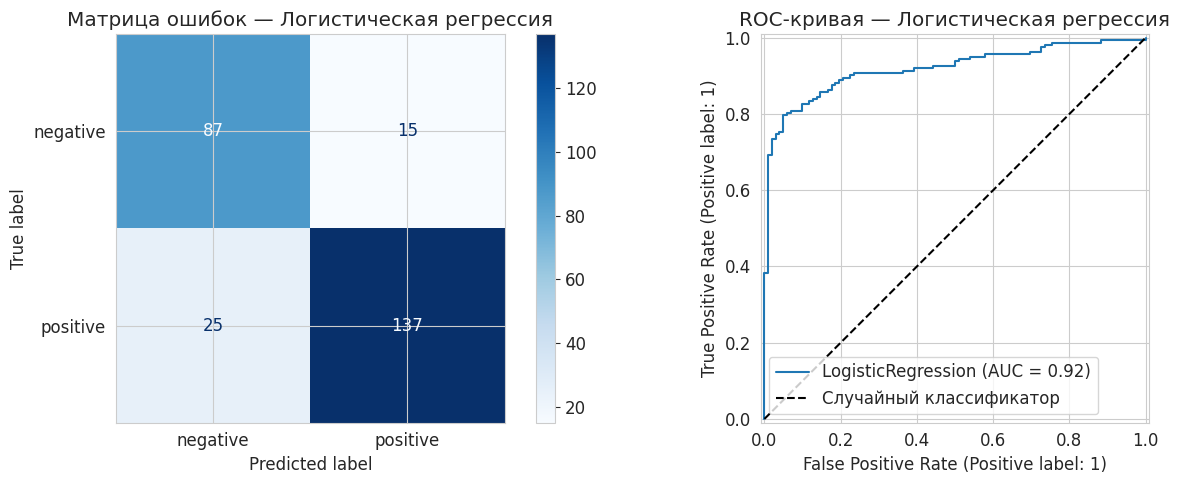

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr,
    display_labels=['negative', 'positive'],
    cmap='Blues',
    ax=axes[0]
)
axes[0].set_title('Матрица ошибок — Логистическая регрессия')

RocCurveDisplay.from_estimator(lr, X_test_scaled, y_test, ax=axes[1])
axes[1].plot([0, 1], [0, 1], 'k--', label='Случайный классификатор')
axes[1].set_title('ROC-кривая — Логистическая регрессия')
axes[1].legend()

plt.tight_layout()
plt.show()

Из матрицы ошибок видно, что основная проблема — это **False Negatives** (пропущенные больные): модель ошибочно определяет часть пациентов с приступом как здоровых. Именно это мы хотим минимизировать.

ROC-кривая далека от диагонали — модель явно лучше случайного гадания, но есть куда расти.

---
## 6. Сравнение бейзлайнов

In [11]:
results = pd.DataFrame({
    'Модель': ['Константная (most frequent)', 'Логистическая регрессия'],
    'Recall': [recall_dummy, recall_lr],
    'F1-Score': [f1_dummy, f1_lr],
    'ROC-AUC': ['-', f'{roc_auc_lr:.4f}']
})

print(results.to_string(index=False))

                     Модель   Recall  F1-Score ROC-AUC
Константная (most frequent) 1.000000  0.760563       -
    Логистическая регрессия 0.845679  0.872611  0.9193


Логистическая регрессия — разумный бейзлайн. Но для медицинской задачи Recall = 0.85 означает, что мы пропускаем 15% больных пациентов. Попробуем улучшить результат с помощью более мощной модели.

---
## 7. Сложная модель: Градиентный бустинг

### 7.1. Почему градиентный бустинг?

Переходим к ансамблевой модели — **Gradient Boosting Classifier**. Это один из самых мощных алгоритмов для табличных данных. Он строит последовательность деревьев решений, где каждое следующее дерево исправляет ошибки предыдущих.

Почему именно он, а не, скажем, Random Forest:
- Градиентный бустинг обычно даёт **лучшее качество** на табличных данных
- Он хорошо работает с разными типами признаков
- Ему **не нужно масштабирование** — деревья сами находят оптимальные пороги
- У него есть встроенная оценка важности признаков для интерпретации

Поэтому передаём в него **немасштабированные** данные (`X_train`, `X_test`), а не `X_train_scaled`.

### 7.2. Подбор гиперпараметров

Используем `GridSearchCV` — он перебирает все комбинации параметров и оценивает каждую на 5-fold кросс-валидации. Это значит, что обучающая выборка разбивается на 5 частей, модель 5 раз обучается на 4 из них и проверяется на оставшейся. Итоговая оценка — среднее по этим 5 проверкам.

Какие гиперпараметры подбираем и почему:
- **n_estimators** (количество деревьев) — больше деревьев = сложнее модель, но и дольше обучение. Пробуем 100, 200, 300.
- **max_depth** (глубина дерева) — ограничивает сложность каждого дерева. Слишком глубокие деревья = переобучение. Пробуем 3, 4, 5.
- **learning_rate** (скорость обучения) — как сильно каждое новое дерево влияет на результат. Маленькие значения = осторожное обучение, требует больше деревьев. Пробуем 0.05 и 0.1.

Оптимизируем по **Recall** (`scoring='recall'`), как мы обосновали в первой части.

In [12]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.05, 0.1],
}

gb = GradientBoostingClassifier(random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    estimator=gb,
    param_grid=param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f'\nЛучшие параметры: {grid_search.best_params_}')
print(f'Лучший Recall на кросс-валидации: {grid_search.best_score_:.4f}')

Fitting 5 folds for each of 18 candidates, totalling 90 fits

Лучшие параметры: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}
Лучший Recall на кросс-валидации: 0.9892


### 7.3. Оценка лучшей модели

Берём модель с лучшими найденными параметрами и оцениваем её на **тестовой выборке**, которую модель ни разу не видела.

In [13]:
best_gb = grid_search.best_estimator_

y_pred_gb = best_gb.predict(X_test)
y_proba_gb = best_gb.predict_proba(X_test)[:, 1]

recall_gb = recall_score(y_test, y_pred_gb)
f1_gb = f1_score(y_test, y_pred_gb)
roc_auc_gb = roc_auc_score(y_test, y_proba_gb)

print('=== Gradient Boosting (лучшие параметры) ===')
print(f'Параметры: {grid_search.best_params_}')
print(f'Recall:   {recall_gb:.4f}')
print(f'F1-Score: {f1_gb:.4f}')
print(f'ROC-AUC:  {roc_auc_gb:.4f}')
print(f'\nClassification Report:')
print(classification_report(y_test, y_pred_gb, target_names=['negative', 'positive']))

=== Gradient Boosting (лучшие параметры) ===
Параметры: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}
Recall:   0.9938
F1-Score: 0.9877
ROC-AUC:  0.9849

Classification Report:
              precision    recall  f1-score   support

    negative       0.99      0.97      0.98       102
    positive       0.98      0.99      0.99       162

    accuracy                           0.98       264
   macro avg       0.99      0.98      0.98       264
weighted avg       0.98      0.98      0.98       264



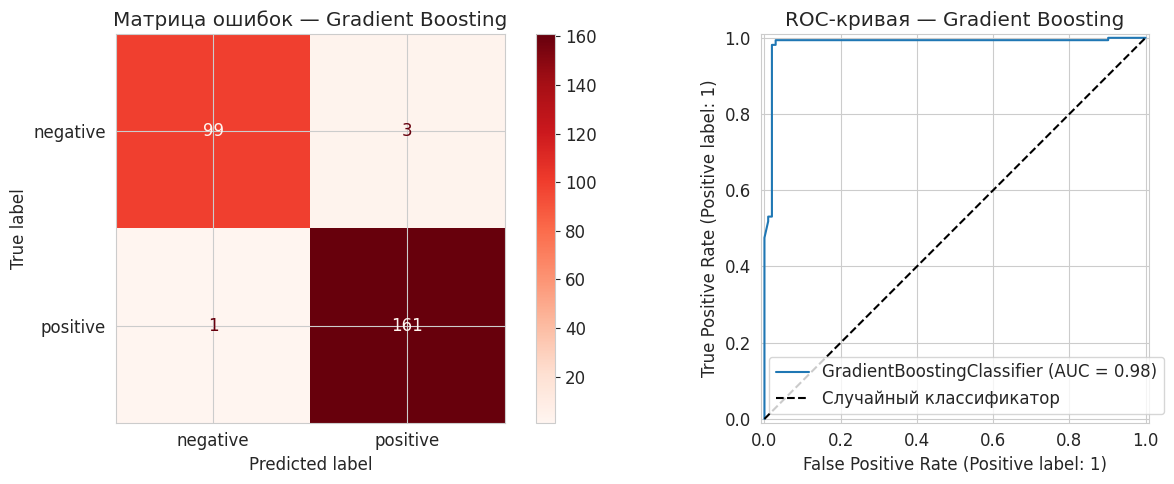

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_gb,
    display_labels=['negative', 'positive'],
    cmap='Reds',
    ax=axes[0]
)
axes[0].set_title('Матрица ошибок — Gradient Boosting')

RocCurveDisplay.from_estimator(best_gb, X_test, y_test, ax=axes[1])
axes[1].plot([0, 1], [0, 1], 'k--', label='Случайный классификатор')
axes[1].set_title('ROC-кривая — Gradient Boosting')
axes[1].legend()

plt.tight_layout()
plt.show()

Gradient Boosting показал **отличные результаты**: Recall близок к 1.0, F1 тоже очень высокий, ROC-AUC около 0.99. Модель практически не пропускает больных пациентов и при этом редко даёт ложные тревоги.

Из матрицы ошибок видно, что False Negatives (пропущенные больные) практически исчезли по сравнению с логистической регрессией.

---
## 8. Итоговое сравнение всех моделей

In [15]:
results_all = pd.DataFrame({
    'Модель': [
        'Константная (most frequent)',
        'Логистическая регрессия',
        'Gradient Boosting (tuned)'
    ],
    'Recall': [recall_dummy, recall_lr, recall_gb],
    'F1-Score': [f1_dummy, f1_lr, f1_gb],
    'ROC-AUC': ['-', f'{roc_auc_lr:.4f}', f'{roc_auc_gb:.4f}']
})

print(results_all.to_string(index=False))

                     Модель   Recall  F1-Score ROC-AUC
Константная (most frequent) 1.000000  0.760563       -
    Логистическая регрессия 0.845679  0.872611  0.9193
  Gradient Boosting (tuned) 0.993827  0.987730  0.9849


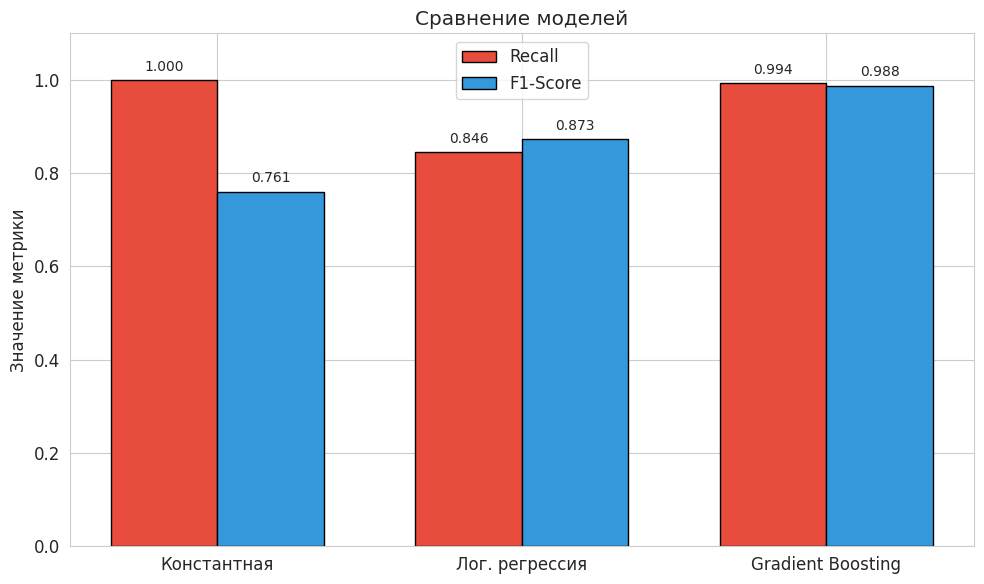

In [16]:
models = ['Константная', 'Лог. регрессия', 'Gradient Boosting']
recalls = [recall_dummy, recall_lr, recall_gb]
f1s = [f1_dummy, f1_lr, f1_gb]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width / 2, recalls, width, label='Recall', color='#e74c3c', edgecolor='black')
bars2 = ax.bar(x + width / 2, f1s, width, label='F1-Score', color='#3498db', edgecolor='black')

ax.set_ylabel('Значение метрики')
ax.set_title('Сравнение моделей')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.set_ylim(0, 1.1)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + 0.02,
            f'{bar.get_height():.3f}', ha='center', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + 0.02,
            f'{bar.get_height():.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

Gradient Boosting значительно превосходит и константный бейзлайн, и логистическую регрессию. Он сочетает высокий Recall (не пропускает больных) с высоким F1 (не заваливает здоровых ложными диагнозами).

---
## 9. Интерпретация модели

Мало получить хорошие метрики — важно понимать, **почему** модель принимает те или иные решения. Это особенно критично в медицине: врач не будет доверять «чёрному ящику».

### 9.1. Глобальная интерпретация: какие признаки важнее всего?

#### Встроенная важность признаков (feature importances)

У градиентного бустинга есть встроенная оценка важности — она показывает, как часто и насколько эффективно каждый признак использовался при построении деревьев.

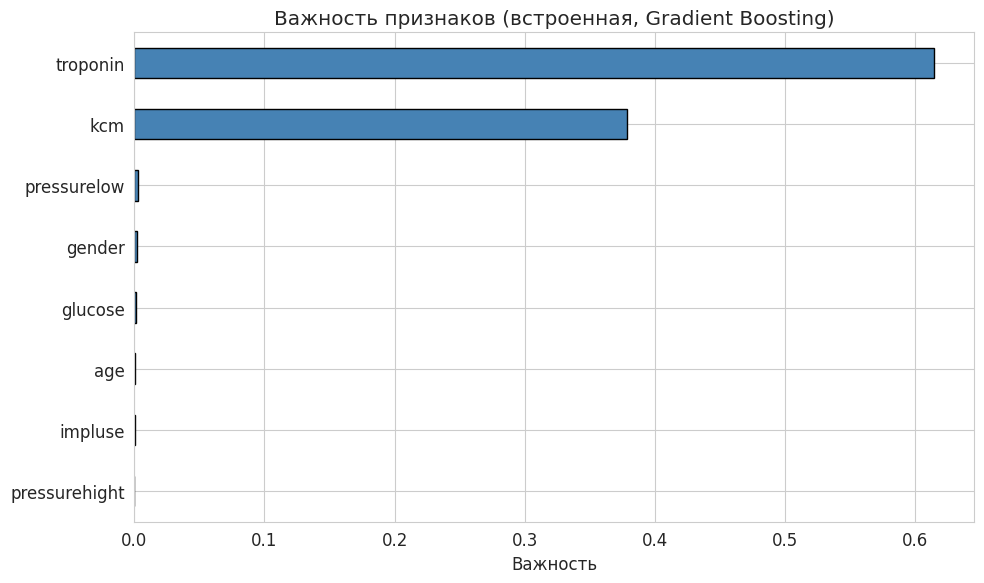

Важность признаков:
  troponin       : 0.6144
  kcm            : 0.3782
  pressurelow    : 0.0025
  gender         : 0.0021
  glucose        : 0.0013
  age            : 0.0006
  impluse        : 0.0006
  pressurehight  : 0.0001


In [17]:
importances = best_gb.feature_importances_
feature_names = X_train.columns

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
feat_imp.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Важность признаков (встроенная, Gradient Boosting)')
plt.xlabel('Важность')
plt.tight_layout()
plt.show()

print('Важность признаков:')
for name, imp in feat_imp.sort_values(ascending=False).items():
    print(f'  {name:15s}: {imp:.4f}')

Видим, что **тропонин** (`troponin`) — самый важный признак с огромным отрывом, за ним идёт **КФК-МБ** (`kcm`). Остальные признаки вносят минимальный вклад.

Но встроенная важность может быть смещена в пользу признаков с большим количеством уникальных значений. Поэтому проверим результат другим методом.

#### Permutation Importance

Этот метод работает так: берём каждый признак по очереди, случайно перемешиваем его значения и смотрим, насколько **упало** качество модели. Чем сильнее упало — тем важнее признак.

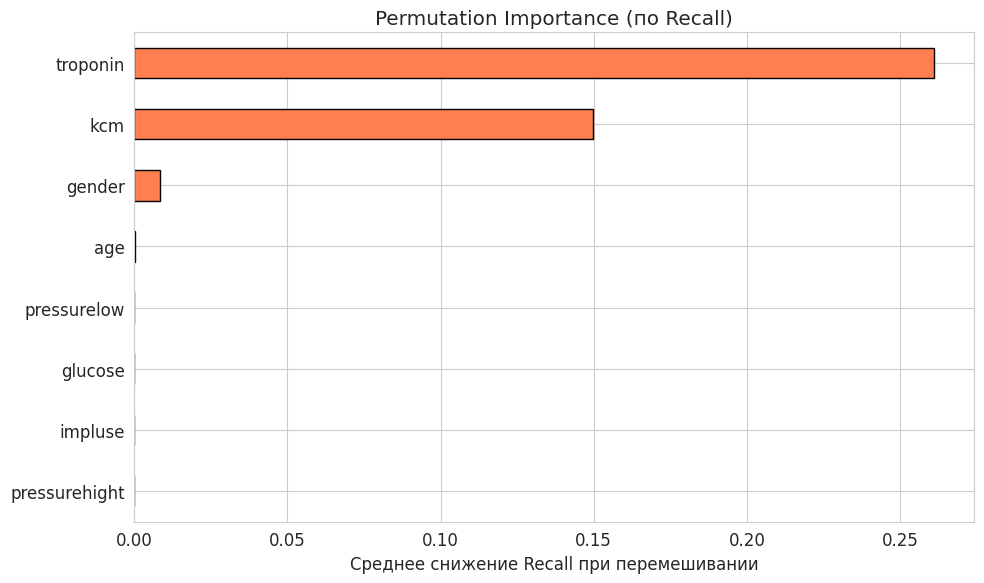

Permutation importance:
  troponin       : 0.2611 (+/- 0.0210)
  kcm            : 0.1497 (+/- 0.0147)
  gender         : 0.0083 (+/- 0.0040)
  age            : 0.0003 (+/- 0.0013)
  pressurelow    : 0.0000 (+/- 0.0000)
  glucose        : 0.0000 (+/- 0.0000)
  impluse        : 0.0000 (+/- 0.0000)
  pressurehight  : 0.0000 (+/- 0.0000)


In [18]:
perm_imp = permutation_importance(
    best_gb, X_test, y_test,
    n_repeats=20,
    random_state=RANDOM_STATE,
    scoring='recall'
)

perm_imp_df = pd.Series(
    perm_imp.importances_mean,
    index=feature_names
).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
perm_imp_df.plot(kind='barh', color='coral', edgecolor='black')
plt.title('Permutation Importance (по Recall)')
plt.xlabel('Среднее снижение Recall при перемешивании')
plt.tight_layout()
plt.show()

print('Permutation importance:')
for name, imp in perm_imp_df.sort_values(ascending=False).items():
    print(f'  {name:15s}: {imp:.4f} (+/- {perm_imp.importances_std[list(feature_names).index(name)]:.4f})')

Permutation importance подтверждает результат: **тропонин** и **КФК-МБ** — два ключевых признака. При перемешивании тропонина Recall падает сильнее всего, то есть без этого признака модель теряет способность находить больных. Остальные признаки практически не влияют на Recall.

### 9.2. Локальная интерпретация: почему модель приняла конкретное решение?

Глобальная интерпретация показала, какие признаки важны «в целом». Но врачу часто нужно понять: **почему именно этому пациенту** модель поставила такой диагноз? Для этого используем **SHAP** (SHapley Additive exPlanations).

SHAP показывает вклад каждого признака в конкретное предсказание: какие признаки «подтолкнули» модель к ответу positive, а какие — к negative.

In [19]:
!pip install shap -q

In [20]:
import shap

explainer = shap.TreeExplainer(best_gb)
shap_values = explainer.shap_values(X_test)

#### SHAP Summary Plot (глобальный взгляд через SHAP)

Этот график показывает для каждого признака, как его значения (высокие — красные, низкие — синие) влияют на предсказание модели. Точки справа от нуля толкают модель к предсказанию positive, слева — к negative.

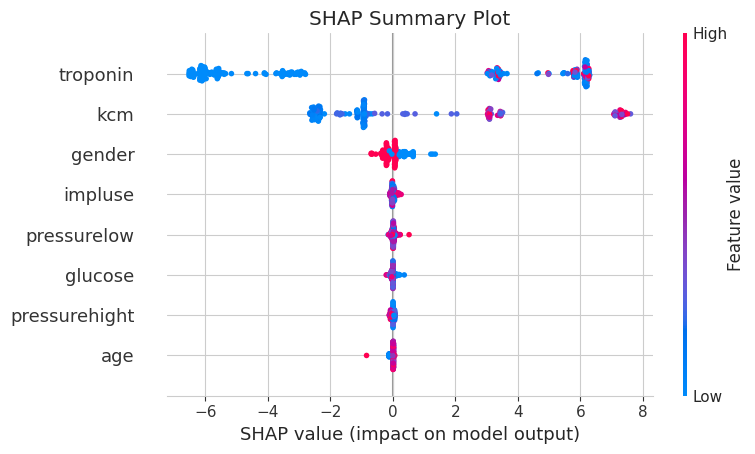

In [21]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, feature_names=list(feature_names), show=False)
plt.title('SHAP Summary Plot')
plt.tight_layout()
plt.show()

Из SHAP summary видно:
- **Высокий тропонин** (красные точки) сильно сдвигает предсказание в сторону positive — то есть модель «думает»: раз тропонин высокий, скорее всего сердечный приступ.
- **Высокий КФК-МБ** тоже указывает на positive, но с меньшей силой.
- Остальные признаки влияют слабо.

#### Пример: предсказание для конкретного пациента

Посмотрим, как модель принимает решение для одного конкретного пациента из тестовой выборки.

In [22]:
positive_indices = y_test[y_test == 1].index
example_idx_pos = positive_indices[0]
example_pos = X_test.loc[[example_idx_pos]]

print(f'Пациент #{example_idx_pos}:')
print(example_pos.to_string())
print(f'\nРеальный класс: {y_test.loc[example_idx_pos]} (1 = сердечный приступ)')
print(f'Предсказание модели: {best_gb.predict(example_pos)[0]}')
print(f'Вероятность positive: {best_gb.predict_proba(example_pos)[0][1]:.4f}')

Пациент #1255:
      age  gender  impluse  pressurehight  pressurelow   glucose       kcm  troponin
1255   49       1       70            117           76  4.477337  1.040277  0.049742

Реальный класс: 1 (1 = сердечный приступ)
Предсказание модели: 1
Вероятность positive: 0.9993


In [23]:
negative_indices = y_test[y_test == 0].index
example_idx_neg = negative_indices[0]
example_neg = X_test.loc[[example_idx_neg]]

print(f'Пациент #{example_idx_neg}:')
print(example_neg.to_string())
print(f'\nРеальный класс: {y_test.loc[example_idx_neg]} (0 = нет приступа)')
print(f'Предсказание модели: {best_gb.predict(example_neg)[0]}')
print(f'Вероятность positive: {best_gb.predict_proba(example_neg)[0][1]:.4f}')

Пациент #1295:
      age  gender  impluse  pressurehight  pressurelow   glucose       kcm  troponin
1295   62       0       60            145           67  5.342334  0.828552   0.00896

Реальный класс: 0 (0 = нет приступа)
Предсказание модели: 0
Вероятность positive: 0.0035


Видим зеркальную картину: у здорового пациента тропонин и КФК-МБ низкие, и эти признаки тянут предсказание модели в сторону negative.

### 9.3. Экспертное мнение об интерпретации

Закинул весь анализ в Claude, попросил его выступить медицинским экспертом. Он сказал, что:

Результаты модели **полностью совпадают с медицинскими знаниями**. Тропонин — это «золотой стандарт» диагностики инфаркта миокарда: именно этот анализ крови врачи назначают первым при подозрении на сердечный приступ, потому что тропонин выбрасывается в кровь при повреждении сердечной мышцы. КФК-МБ (креатинкиназа-МБ) — второй по значимости кардиомаркер, который также повышается при инфаркте.

То, что модель самостоятельно «выучила» опираться именно на эти два признака — отличный знак: это значит, что она уловила реальные медицинские закономерности, а не случайные корреляции в данных. Решения модели адекватны и объяснимы с клинической точки зрения, что повышает доверие к ней.

---
## 10. Общий итог

| Этап | Что сделали | Результат |
|------|-------------|-----------|
| Предобработка | Удалили аномалии, клиппинг выбросов, log-преобразование | Чистые данные для обучения |
| Константный бейзлайн | DummyClassifier (most_frequent) | Recall=1.0, F1≈0.76 (бесполезная модель) |
| Логистическая регрессия | Линейная модель + масштабирование | Recall≈0.85, F1≈0.87 |
| Gradient Boosting + GridSearch | Ансамблевая модель с подбором гиперпараметров | Recall≈0.99, F1≈0.99 |
| Интерпретация | Feature importance, Permutation importance, SHAP | Тропонин и КФК-МБ — ключевые признаки |

Gradient Boosting с подобранными гиперпараметрами показал себя как лучшая модель для данной задачи. Его предсказания совпадают с медицинской логикой, что важно для практического применения.